In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import coint_johansen

In [5]:
df=pd.read_csv("data.csv")
df.head()


,Unnamed: 0,day,timestep,IND,AAA,BBB,CCC,DDD,ETF
0,0,1,0,99.13,196.87,307.09,247.92,153.15,226.26
1,1,1,1,99.14,196.66,306.36,247.69,153.18,225.97
2,2,1,2,99.17,196.83,306.89,246.54,153.12,225.84
3,3,1,3,98.99,196.72,307.67,246.80,153.23,226.11
4,4,1,4,98.94,196.36,305.95,246.61,153.30,225.56


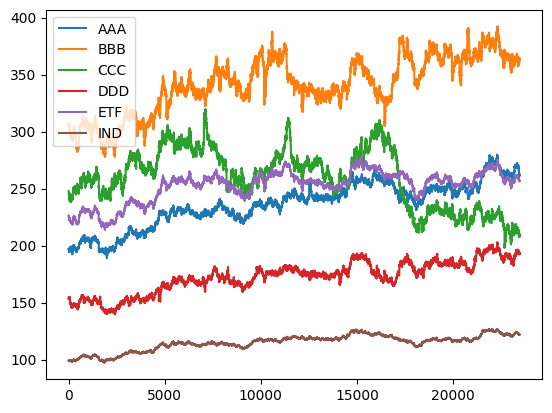

In [6]:
stock_codes=["AAA","BBB","CCC","DDD","ETF","IND"]
#fig, ax = plt.subplots(figsize=(15, 5))
#balance= pd.Series(train_data['resp']).cumsum()
#ax.set_xlabel ("Trade", fontsize=18)
#ax.set_ylabel ("Cumulative resp", fontsize=18);
for name in stock_codes:
    plt.plot(df.index,df[name],label=name)

plt.legend()


In [ ]:
for i in range(len(stock_codes)):
    pricediff = None
    for j in range(i+1, len(stock_codes)):
        stock_code1 = stock_codes[i]
        stock_code2 = stock_codes[j]
        
        data1 = df[stock_code1]
        data2 = df[stock_code2]

        result=pd.DataFrame()
        result[stock_code1]=data1
        result[stock_code2]=data2
        #print(result.head())
        cj = coint_johansen(result[['close_x', 'close_y']], det_order=1, k_ar_diff=1)

In [ ]:
        
        cj = coint_johansen(result[['close_x', 'close_y']], det_order=1, k_ar_diff=1)
        if cj.trace_stat[0] > cj.trace_stat_crit_vals[0][1]:
            print(f"Cointegration found for {stock_code1} and {stock_code2}")
            pricediff = result[['close_x', 'close_y']] @ cj.evec[0]
            break
    if pricediff is not None:
        break